# 클래스 불균형
- 클래스 불균형(Class Imbalances) 문제의 경우 알고리즘이 다수 클래스를 더 많이 예측하는 방향으로 편향되는 경향이 있음. 따라서 소수 클래스에서 오분류율이 높아짐
- 비즈니스 상황에서 클래스 불균형은 흔한 현상
    - 금융 비정상 거래 예측 : 정상 > 비정상(사기거래)
    - 제조 공정간 불량 예측 : 정상 > 불량
- 이러한 경우 왜 문제인가?
    - 정확도(Accuracy)는 높지만, 소수 클래스의 재현율(Recall)는 형편없이 낮음

- 해결방법1 : Resampling
    - Under Sampling : 다수 클래스 데이터를 소수 클래스 수 만큼 랜덤 샘플링
    - Over Sampling : 소수 클래스 데이터를 다수 클래스 수 만큼 랜덤 샘플링

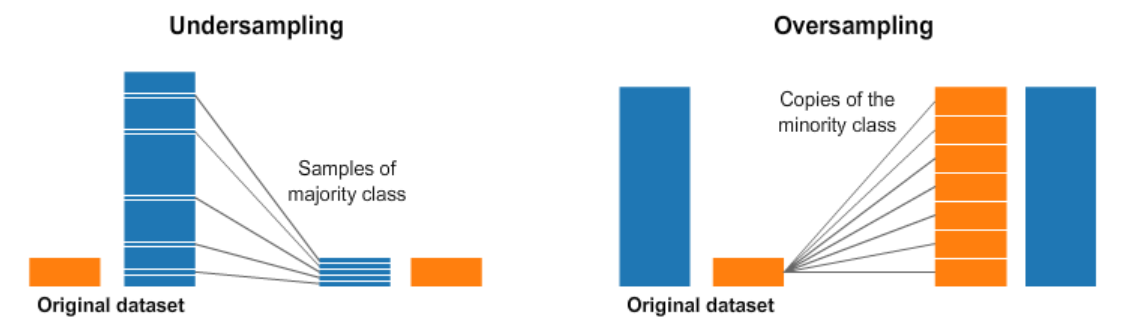

- 해결방법2 : Class Weight
    - Resampling 없이 클래스에 가중치를 부여하여 클래스 불균형 문제 해결
        - 학습 중 소수 클래스에 더 많은 가중치를 부여
        - 소수 클래스에 대한 오류를 줄이는 효과

# 1.환경 준비

In [ ]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format = 'retina'

In [ ]:
# 데이터 읽어오기
path = '../data/attrition2.csv'
df = pd.read_csv(path)

# 2.데이터 이해

In [ ]:
# 상위 몇 개 행 확인
df.head()

In [ ]:
# 하위 몇 개 행 확인
df.tail()

In [ ]:
# 변수 확인
df.info()

In [ ]:
# Target 확인
print(df['Attrition'].value_counts())

# 시각화
df['Attrition'].value_counts().plot(kind='barh')
plt.show()

# 3.데이터 전처리

**1) 가변수화**

In [ ]:
# 가변수화
dumm_cols = ['Education', 'Department', 'EducationField', 'Gender', 'JobRole', 'JobSatisfaction',
             'MaritalStatus', 'RelationshipSatisfaction', 'WorkLifeBalance']

df = pd.get_dummies(df, columns=dumm_cols, drop_first=True)

**2) x, y 분리**

In [ ]:
# target 확인
target = 'Attrition'

# 데이터 분리
X = df.drop(target, axis=1)
y = df.loc[:, target]

**3) 학습용, 평가용 데이터 분리**

In [ ]:
# 모듈 불러오기
from sklearn.model_selection import train_test_split

# 7:3으로 분리
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=1)

# 4.모델링

## 4.1.기본 모델링

- 원본 데이터를 사용해 Random Forest 알고리즘으로 모델링한다.

In [ ]:
# 학습 데이터 분포 확인
sns.scatterplot(x='Age', y='MonthlyIncome', hue=y_train, data=X_train)
plt.show()

In [ ]:
# 불러오기
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *

# 선언하기
model = RandomForestClassifier(max_depth=5, random_state=1)

# 학습하기
model.fit(X_train, y_train)

# 예측하기
y_pred = model.predict(X_test)

# 평가하기
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

- Accuracy(정확도)는 높지만 Target 값 1에 대한 Recall(재현율, 민감도)이 매우 낮다.
- 전체 데이터 중에서 Target 값이 1인 데이터가 매우 적기 때문이다.
- 이러한 현상을 **클래스 불균형** 이라고 하는데, 실무에서는 Accuracy가 낮아지더라도 1에 대한 Recall을 높여야 할 경우가 종종 있다.
- 이를 위해 **Under Sampling** 또는 **Over Sampling** 을 사용한다.

## 4.2.Under Sampling

- Under Sampling 후 모델 성능을 확인한다.

**1) Under Sampling**

- RandomUnderSampler를 사용해 Under Sampling 한다.

In [ ]:
# imblearn 설치
#!pip install imbalanced-learn

In [ ]:
# 불러오기
from imblearn.under_sampling import RandomUnderSampler

# Under Sampling
under_sample = RandomUnderSampler()
u_X_train, u_y_train = under_sample.fit_resample(X_train, y_train)

# 확인
print('전:', np.bincount(y_train))
print('후:', np.bincount(u_y_train))

**2) 학습 데이터 분포 확인**

- 시각화해서 Resampling 된 학습 데이터 분포 확인

In [ ]:
# 학습 데이터 분포 확인
sns.scatterplot(x='Age', y='MonthlyIncome', hue=u_y_train, data=u_X_train)
plt.show()

**3) 모델 성능 확인**

- 다시 모델링해 성능을 확인한다.

In [ ]:
# 선언하기
model = RandomForestClassifier(max_depth=5, random_state=1)

# 학습하기
model.fit(u_X_train, u_y_train)

# 예측하기
y_pred = model.predict(X_test)

# 평가하기
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

## 4.3.Over Sampling #1

- Over Sampling 후 모델 성능을 확인한다.

**1) Over Sampling**

- RandomOverSampler를 사용해 Over Sampling 한다.

In [ ]:
# 불러오기
from imblearn.over_sampling import RandomOverSampler

# Over Sampling
over_sample = RandomOverSampler()
o_X_train, o_y_train = over_sample.fit_resample(X_train, y_train)

# 확인
print('전:', np.bincount(y_train))
print('후:', np.bincount(o_y_train))

**2) 학습 데이터 분포 확인**

- 시각화해서 Resampling 된 학습 데이터 분포 확인

In [ ]:
# 학습 데이터 분포 확인
sns.scatterplot(x='Age', y='MonthlyIncome', hue=o_y_train, data=o_X_train)
plt.show()

**3) 모델 성능 확인**

- 다시 모델링해 성능을 확인한다.

In [ ]:
# 선언하기
model = RandomForestClassifier(max_depth=5, random_state=1)

# 학습하기
model.fit(o_X_train, o_y_train)

# 예측하기
y_pred = model.predict(X_test)

# 평가하기
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

## 4.4.Over Sampling #2

- Over Sampling 후 모델 성능을 확인한다.

**1) Over Sampling**

- SMOTE를 사용해 Over Sampling 한다.
- SMOTE(Synthetic Minority Over-sampling Technique)
- SMOTE는 소수 클래스 샘플을 단순 복제하는 것이 아니라, 기존 샘플을 기반으로 새로운 샘플을 합성하여 생성하는 기법이다.

In [ ]:
# 불러오기
from imblearn.over_sampling import SMOTE

# Over Sampling
smote = SMOTE()
s_X_train, s_y_train = smote.fit_resample(X_train, y_train)

# 확인
print('전:', np.bincount(y_train))
print('후:', np.bincount(s_y_train))

**2) 학습 데이터 분포 확인**

- 시각화해서 Resampling 된 학습 데이터 분포 확인

In [ ]:
# 학습 데이터 분포 확인
sns.scatterplot(x='Age', y='MonthlyIncome', hue=s_y_train, data=s_X_train)
plt.show()

**3) 모델 성능 확인**

- 다시 모델링해 성능을 확인한다.

In [ ]:
# 선언하기
model = RandomForestClassifier(max_depth=5, random_state=1)

# 학습하기
model.fit(s_X_train, s_y_train)

# 예측하기
y_pred = model.predict(X_test)

# 평가하기
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

## 4.5.Class Weight

- class_weight 하이퍼파라미터를 설정해 모델링한 후 성능을 확인한다.
- sklearn에서 제공하는 알고리즘 대부분 class_weight라는 하이퍼파라미터 제공

In [ ]:
# 선언하기
model = RandomForestClassifier(max_depth=5, random_state=1, class_weight='balanced')

# 학습하기
model.fit(X_train, y_train)

# 예측하기
y_pred = model.predict(X_test)

# 평가하기
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))